---
title: "Barycentric formula and divided differences"
subtitle: "Lecture 8: Chapter 3: Polynomial interpolation"
code-fold: true
format:
  html: default
  pdf: default
---

{{< include ../extras/_lecture-header.html >}}

In [2]:
# | include: false

# IF YOU ARE READING THIS, LET ME KNOW 
# AND I'LL GIVE OUT CHOCOLATE IN THE 
# NEXT LECTURE

using Plots, LaTeXStrings, Polynomials, Printf 

## Previously.....

- Interpolation, Taylor expansion, Lagrange interpolation, 
- Thm: there exists a unique polynomial $p \in \mathcal P_n$ solving Lagrange interpolation problem on $n+1$ distinct nodes, 
- Proof: uses Lagrange polynomials $\ell_j(x) = \prod_{k\not=j} (x-x_k)/(x_j-x_k)$, 
- Error estimate: Taylor-like remainder estimate depending on derivatives of $f$ and the *node polynomial* $\ell_X(x) = (x-x_0)(x-x_1) \dots (x-x_n)$, 
- Runge: Equispaced points bad, 
- Chebyshev nodes much better, 
- Chebyshev nodes of the first kind minimise $\| \ell_X \|_{L^\infty([-1,1])} = 2^{-n}$ (where $X$ has $n+1$ nodes), 
- Proof: Chebyshev polynomials (of the first kind) solve the *Chebyshev problem*,
- Chebyshev nodes of the second kind give $\| \ell_X \|_{L^\infty([-1,1])} \leq 2^{1-n}$,

::: {.box}

**Exercise.** @exr-l07-XII

:::


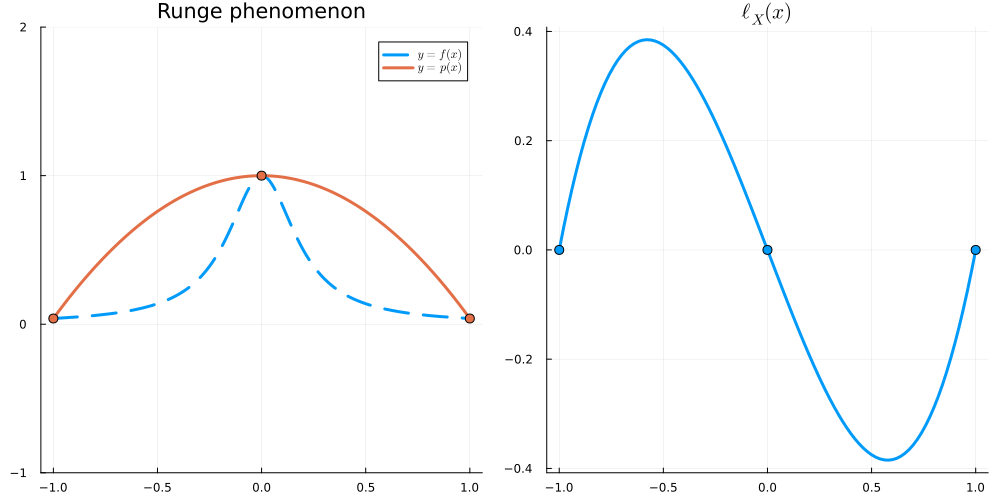


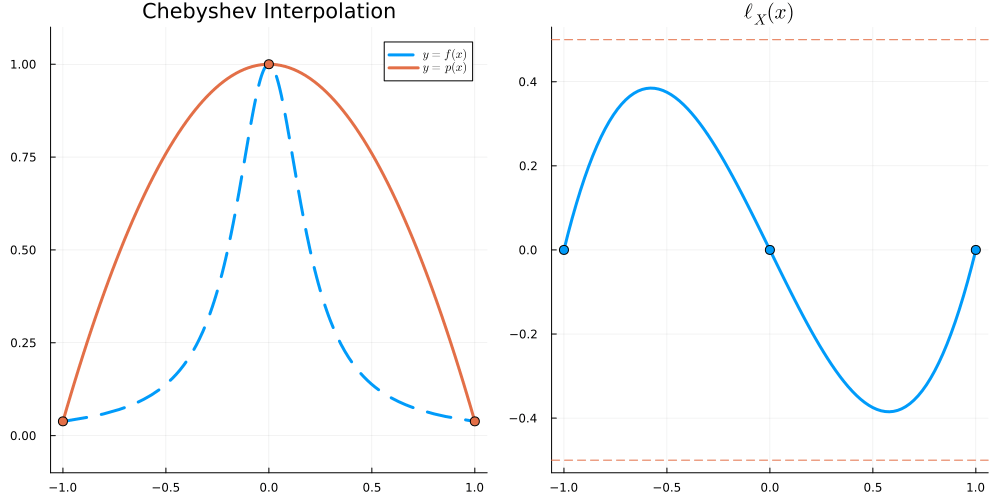



## Barycentric formula

See e.g. @BerrutTrefethen2004 [link](https://people.maths.ox.ac.uk/trefethen/barycentric.pdf) for more details.  

::: {#exr-Bary-1}

Let's use the formula

$$
\begin{align}
    I_Xf(x) &= \sum_{j=0}^n f(x_j) \ell_j(x), \\
    %
    \ell_j(x) &:= \prod_{k\not=j} \frac{x - x_k}{x_j - x_k} \nonumber
\end{align}
$$ {#eq-interpolation-naive}

to compute the polynomial interpolation of $f(x) = \frac1{1+25x^2}$ (Runge function, as above):

Plots.AnimatedGif("c:\\Users\\jack6\\Projects\\Math5485-Fall-2026\\images\\Naive Lagrange.gif")
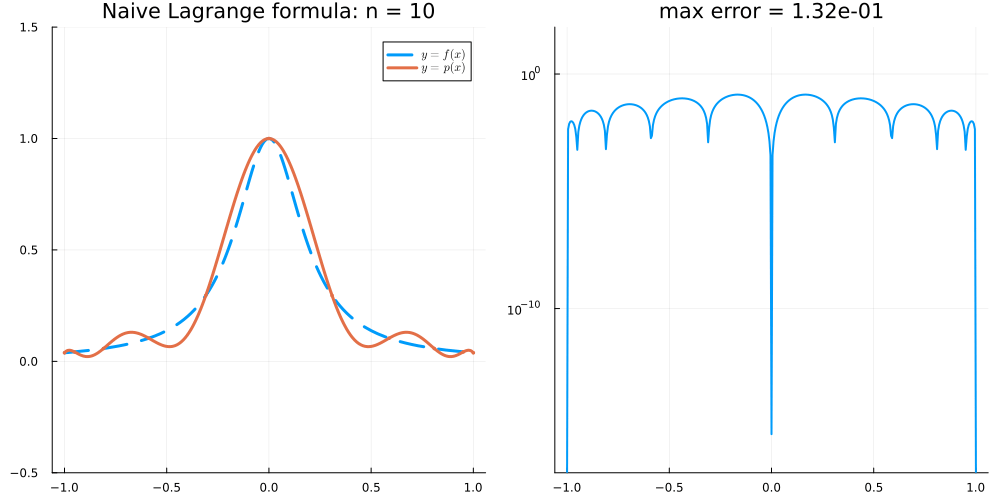

In [3]:
#| classes: animation

Runge = t -> 1/(1 + 25t^2)

function ℓⱼ( j, t, x ) 
    if j == 0
        return prod( @. t - x[2:end] ) / prod( @. x[1] - x[2:end] )
    elseif j == length(x)-1 
        return prod( @. t - x[1:end-1] ) / prod( @. x[end] - x[1:end-1] )
    else
        return prod( @. t - x[1:j] ) * prod( @. t - x[(j+2):end] ) / ( prod( @. x[j+1] - x[1:j] ) * prod( @. x[j+1] - x[(j+2):end] ) )
    end
end 

function p_naive( t, x, y ) 
    r = 0
    for j in 0:(length(x)-1)
        r = r + ℓⱼ(j, t, x) * y[j+1] 
    end
    return r
end 

egrid = range(-1, 1, length=401)

anim = @animate for n ∈ [10, 20, 50, 100, 200, 400, 600, 700, 760, 780:20:1020...]
    x = @. cos( π*(0:n)/n )
    y = @. Runge( x )
    p = p_naive.( egrid, Ref(x), Ref(y) )
    err = @. max( abs( p - Runge(egrid) ), 1e-17 )

    plt1 = plot(Runge, -1, 1; label=L"y = f(x)", lw = 3, linestyle = :dash, 
            title = "Naive Lagrange formula: n = $n", ylims = (-0.5, 1.5))
    plot!(plt1, egrid, p; label=L"y = p(x)", lw = 3 )
    scatter!(plt1, x, y; primary = false, markersize = 2, markerstrokewidth = 0)

    plt2 = plot(egrid, err; yscale = :log10, ylims = (1e-17, 1e2), legend = false, lw = 2,
            title = @sprintf("max error = %.2e", maximum(err)))
    plot( plt1, plt2; size=(1000, 500) )
end

gif(anim, "../images/Naive Lagrange.gif", fps = 1, show_msg = false)



What is happening here?

::: {.exercise-hint style="display:none;"}

Underflow! The products $\prod_{k} (t - x_k)$ and $\prod_{k\not=j} (x_j - x_k)$ are of size roughly $2^{-n}$ (and the partial products computed in the code can be even smaller). Around $n \approx 800$, these partial products fall below the smallest normal double ($\approx 2.2 \times 10^{-308}$) into the subnormal range, where precision is lost.

:::

:::


Notice also that, in order to compute @eq-interpolation-naive, we need $O(n^2)$ operations (flops) for each $x$ - so it is slow and unstable!

Instead, we may use the *Barycentric formula* which we now derive. First notice that 

$$
\begin{align}
    \ell_j(x) &= \prod_{k \not= j} \frac{x - x_k}{x_j - x_k} 
    \nonumber\\
    %
    &= \lambda_j \frac{\ell_X(x)}{x- x_j}
\end{align}
$$ {#eq-ell-j}

where $\lambda_j := \frac{1}{ \prod_{k \not= j} (x_j - x_k) }$. As a result, we have 

$$
\begin{align}
    I_Xf(x) &= \sum_{j=0}^n f(x_j) \ell_j(x) \nonumber \\
    %
    &= \ell_X(x) \sum_{j=0}^n \frac{\lambda_j f(x_j)}{x- x_j}.
\end{align}
$$

This is sometimes referred to as the *first form of the Barycentric formula*.

::: {#exr-sum-lagrange-1}

Suppose that $X = \{ x_0 < ... < x_n \}$ and let $\ell_j$ be the corresponding Lagrange polynomials. Show that $\sum_{j=0}^n \ell_j(x) = 1$ for all $x$.

:::

Therefore, using @eq-ell-j and dividing by $\sum_{j=0}^n \ell_j(x) = 1$, we obtain (for $x \not\in X$)

$$
\begin{align}
    I_Xf(x) &= \left. \sum_{j=0}^n \ell_j(x) f(x_j) \middle/ \sum_{j=0}^n \ell_j(x) \right. \nonumber\\
    &= \left. \ell_X(x) \sum_{j=0}^n \frac{\lambda_j f(x_j)}{x - x_j} \middle/ \ell_X(x) \sum_{j=0}^n \frac{\lambda_j}{x - x_j} \right. \nonumber\\
    &= \left. \sum_{j=0}^n \frac{\lambda_j f(x_j)}{x - x_j} \middle/ \sum_{j=0}^n \frac{\lambda_j}{x - x_j} \right.
\end{align}
$$ {#eq-Barycentric}

which is known as the *Barycentric formula*. 

For a fixed interpolation set, one may compute $\lambda_j$ once and then evaluating $p(x)$ requires only $O(n)$ computations. 

In fact, for Chebyshev nodes $X_{\mathrm{II}} = \big\{ \cos \frac{j\pi}{n} \big\}_{j=0}^n$, we have a simple formula for the $\lambda_j$:

$$
    \lambda_j = \begin{cases}
        \frac{2^{n}}{4n}  & \text{if } j = 0 \\
        (-1)^j \frac{2^{n}}{2n} & \text{if } j = 1,\dots,n-1 \\
        (-1)^n \frac{2^{n}}{4n} & \text{if } j = n
    \end{cases}
$$ {#eq-Barycentric-Chebyshev-II}

::: {#exr-Bary-weights}

Explain why one may instead consider any weights of the form $w_j := C \lambda_j$ in the Barycentric formula @eq-Barycentric. Why might this be a good idea? See @eq-Barycentric-Chebyshev-II for the weights appearing in the Barycentric formula for Chebyshev nodes of the second kind.

:::

In particular, for Chebyshev nodes of the second kind, we can use @eq-Barycentric with the weights $w_j := (-1)^j \tau_j$ where $\tau_j = \frac12$ for $j=0, n$ and $\tau_j = 1$ otherwise. Moreover, this formula has been proved to be numerically stable (@Higham2004) which we demonstrate in the following:

Plots.AnimatedGif("c:\\Users\\jack6\\Projects\\Math5485-Fall-2026\\images\\Barycentric.gif")
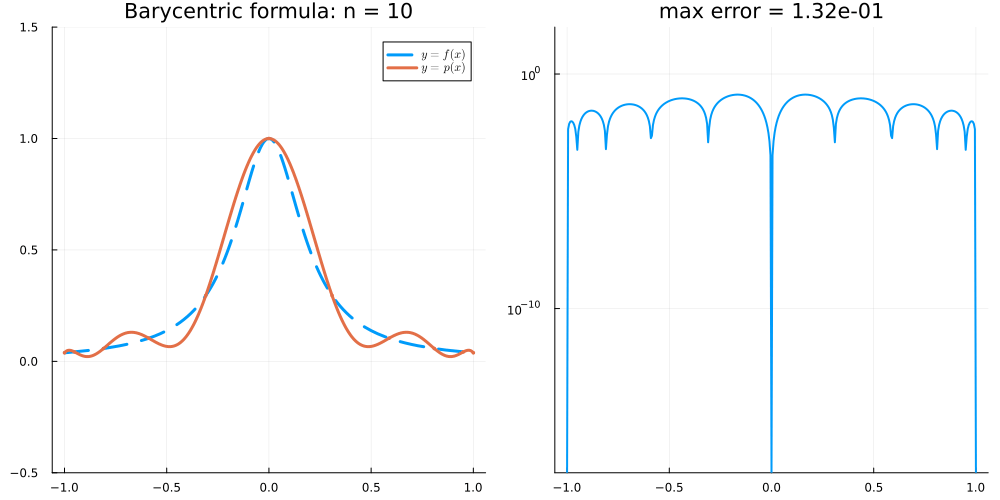

In [ ]:
#| classes: animation

# Barycentric formula for Chebyshev nodes of the second kind:
function ChebyshevInterpolant( f, n )
    x = @. cos( π*(0:n)/n )
    y = @. f( x )
    λ = @. (-1.0)^(0:n)
    λ[1] /= 2
    λ[end] /= 2

    return function ( t )
        num = 0.0
        den = 0.0
        for j ∈ 1:(n+1)
            if t == x[j]
                return y[j]
            end
            num += λ[j] * y[j] / (t - x[j])
            den += λ[j] / (t - x[j])
        end
        return num / den
    end
end

egrid = range(-1, 1, length=401)

anim = @animate for n ∈ [10, 20, 50, 100, 200, 400, 600, 700, 760, 780:20:1020..., 1500, 2000, 5000, 10000]
    x = @. cos( π*(0:n)/n )
    p = ChebyshevInterpolant( Runge, n ).( egrid )
    err = @. max( abs( p - Runge(egrid) ), 1e-17 )

    plt1 = plot(Runge, -1, 1; label=L"y = f(x)", lw = 3, linestyle = :dash, 
            title = "Barycentric formula: n = $n", ylims = (-0.5, 1.5))
    plot!(plt1, egrid, p; label=L"y = p(x)", lw = 3 )
    scatter!(plt1, x, Runge.(x); primary = false, markersize = 2, markerstrokewidth = 0)

    plt2 = plot(egrid, err; yscale = :log10, ylims = (1e-17, 1e2), legend = false, lw = 2,
            title = @sprintf("max error = %.2e", maximum(err)))
    plot( plt1, plt2; size=(1000, 500) )
end

gif(anim, "../images/Barycentric.gif", fps = 1, show_msg = false)


::: {#exr-Bary-2}

Recall that the degree $2$ polynomial interpolation of $f(x) = \sin x$ on $X = \{ x_0 < x_1 < x_2 \} = \{ 0, \frac\pi2, \pi \}$ is $I_X f(x) = -\frac4{\pi^2} x(x-\pi)$. Write the Barycentric version of this formula @eq-Barycentric.

Explain how you would have to update this formula if we added an extra point $x_{3} = -2\pi$ to the interpolation set.

::: {.exercise-solution style="display: none;"}

The Barycentric formula @eq-Barycentric depends on the weights $\lambda_j = \prod_{k\not=j} (x_j-x_k)^{-1}$ which in this case are given by 

$$
\begin{align}
    \lambda_0 &= \frac{1}{(0-\frac\pi2)(0-\pi)} = \frac2{\pi^2}, \nonumber\\
    \lambda_1 &= \frac{1}{(\frac\pi2-0)(\frac\pi2 - \pi)} = -\frac4{\pi^2}, \nonumber\\
    \lambda_2 &= \frac{1}{(\pi - 0)(\pi-\frac\pi2)} = \frac2{\pi^2}
\end{align}
$$

(which makes sense because $\{ 0, \frac\pi2, \pi \}$ are Chebyshev nodes of the second kind scaled to $[0,\pi]$. The scaling only multiplies all of the weights by a common constant, which cancels in the Barycentric formula. In general, the Chebyshev weights can be chosen to be $\frac12, -1, 1, -1, \dots, (-1)^{n-1}, \frac{(-1)^n}{2}$.) 

Since $f(x_{j}) = 0$ for $j=0,2$, we have 

$$
\begin{align}
    I_Xf(x) &= \left.\left( 
        \frac{\lambda_0 f(x_0)}{x - x_0} + \frac{\lambda_1 f(x_1)}{x - x_1} + \frac{\lambda_2 f(x_2)}{x - x_2}
    \right) \middle/ \left( 
        \frac{\lambda_0}{x - x_0} + \frac{\lambda_1}{x - x_1} + \frac{\lambda_2}{x - x_2}
    \right) \right. \nonumber\\
    %
    &= \left.\left( 
        \frac{-1}{x - \frac\pi2}
    \right) \middle/ \left( 
        \frac{1/2}{x} + \frac{-1}{x - \frac\pi2} + \frac{1/2}{x - \pi}
    \right) \right.
\end{align}
$$

where, in the second line, we have multiplied all of the weights by $\frac{\pi^2}{4}$ (which does not change the formula) to obtain the weights $\frac12, -1, \frac12$.

We would have to update $\lambda_{j}$ by dividing by $x_{j} - (-2\pi)$ for each $j=0,1,2$ so we get $\lambda_0,\lambda_1,\lambda_2 = \frac{1}{\pi^3}, -\frac{8}{5\pi^3}, \frac{2}{3\pi^3}$ and write down 

$$
\begin{align}
    \lambda_3 = \frac{1}{(-2\pi-0)(-2\pi-\frac\pi2)(-2\pi-\pi)} = -\frac{1}{15\pi^3}
\end{align}
$$

:::
:::


::: {.callout-tip collapse="true"}
# Solution

The Barycentric formula @eq-Barycentric depends on the weights $\lambda_j = \prod_{k\not=j} (x_j-x_k)^{-1}$ which in this case are given by 

$$
\begin{align}
    \lambda_0 &= \frac{1}{(0-\frac\pi2)(0-\pi)} = \frac2{\pi^2}, \nonumber\\
    \lambda_1 &= \frac{1}{(\frac\pi2-0)(\frac\pi2 - \pi)} = -\frac4{\pi^2}, \nonumber\\
    \lambda_2 &= \frac{1}{(\pi - 0)(\pi-\frac\pi2)} = \frac2{\pi^2}
\end{align}
$$

(which makes sense because $\{ 0, \frac\pi2, \pi \}$ are Chebyshev nodes of the second kind scaled to $[0,\pi]$. The scaling only multiplies all of the weights by a common constant, which cancels in the Barycentric formula. In general, the Chebyshev weights can be chosen to be $\frac12, -1, 1, -1, \dots, (-1)^{n-1}, \frac{(-1)^n}{2}$.) 

Since $f(x_{j}) = 0$ for $j=0,2$, we have 

$$
\begin{align}
    I_Xf(x) &= \left.\left( 
        \frac{\lambda_0 f(x_0)}{x - x_0} + \frac{\lambda_1 f(x_1)}{x - x_1} + \frac{\lambda_2 f(x_2)}{x - x_2}
    \right) \middle/ \left( 
        \frac{\lambda_0}{x - x_0} + \frac{\lambda_1}{x - x_1} + \frac{\lambda_2}{x - x_2}
    \right) \right. \nonumber\\
    %
    &= \left.\left( 
        \frac{-1}{x - \frac\pi2}
    \right) \middle/ \left( 
        \frac{1/2}{x} + \frac{-1}{x - \frac\pi2} + \frac{1/2}{x - \pi}
    \right) \right.
\end{align}
$$

where, in the second line, we have multiplied all of the weights by $\frac{\pi^2}{4}$ (which does not change the formula) to obtain the weights $\frac12, -1, \frac12$.

We would have to update $\lambda_{j}$ by dividing by $x_{j} - (-2\pi)$ for each $j=0,1,2$ so we get $\lambda_0,\lambda_1,\lambda_2 = \frac{1}{\pi^3}, -\frac{8}{5\pi^3}, \frac{2}{3\pi^3}$ and write down 

$$
\begin{align}
    \lambda_3 = \frac{1}{(-2\pi-0)(-2\pi-\frac\pi2)(-2\pi-\pi)} = -\frac{1}{15\pi^3}
\end{align}
$$

We plot both interpolants (using the Barycentric formula with the weights above):

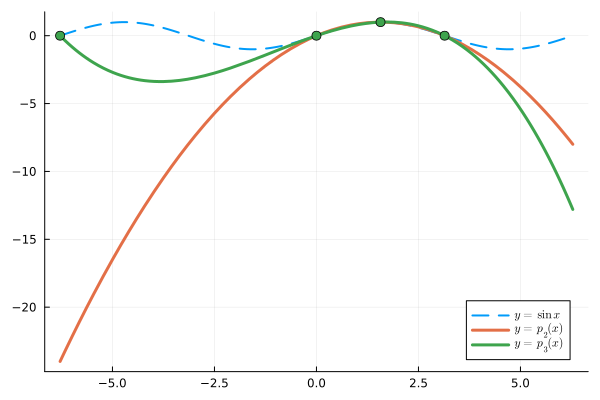

In [ ]:
# Barycentric formula with the weights computed above
function bary( t, x, λ, y )
    i = findfirst( ==(t), x )
    isnothing(i) || return y[i]
    return sum( @. λ * y / (t - x) ) / sum( @. λ / (t - x) )
end

x2 = [0, π/2, π];        λ2 = [2, -4, 2] / π^2
x3 = [0, π/2, π, -2π];   λ3 = [1, -8/5, 2/3, -1/15] / π^3

plot(sin, -2π, 2π; label=L"y = \sin x", lw=2, linestyle=:dash)
plot!(t -> bary(t, x2, λ2, sin.(x2)), -2π, 2π; label=L"y = p_2(x)", lw=3)
plot!(t -> bary(t, x3, λ3, sin.(x3)), -2π, 2π; label=L"y = p_3(x)", lw=3)
scatter!(x3, sin.(x3); markersize=5, primary=false)

:::

## Newton form & divided differences

Fix $X = \{x_0, x_1, \cdots, x_{n} \}$. *Newton polynomials* are the node polynomials corresponding to the first nodes in $X$:

$$
\begin{align}
    \pi_0(x) &= 1 \nonumber\\
    \pi_1(x) &= \ell_{\{x_0\}}(x) = (x - x_0) \nonumber\\
    \pi_2(x) &= \ell_{\{ x_0, x_1 \}}(x) = (x - x_0)(x-x_1) \nonumber\\
    &\vdots \nonumber\\
    \pi_n(x) &= \ell_{\{ x_0, x_1, \dots, x_{n-1} \}}(x) = (x-x_0)(x-x_1)\cdots (x-x_{n-1})
\end{align}
$$

::: {#exm-Newton-1}

Recall that the Lagrange interpolation of $f(x) = \sin x$ on $X = \{ 0, \frac\pi2, \pi \}$ is $I_Xf(x) = -\frac4{\pi^2} x(x-\pi)$. 

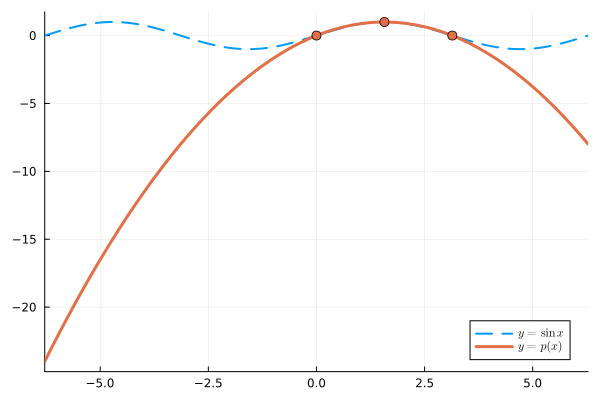

In [ ]:
f = x->sin(x)

x = [0, pi/2, pi]
y = f.(x)

p = fit(x,y)
plot(f, -2pi, 2pi,  label=L"y = \sin x", lw=2, linestyle=:dash)
plot!( p, xlims=(-2pi,2pi), label=L"y= p(x)", lw=3)
scatter!( x, y, markersize=5, primary=false)

Derive the same result using the Newton basis $\pi_0 = 1$, $\pi_1 = x$, and $\pi_2 = x(x-\tfrac\pi2)$.


::: {.exercise-solution style="display:none"}

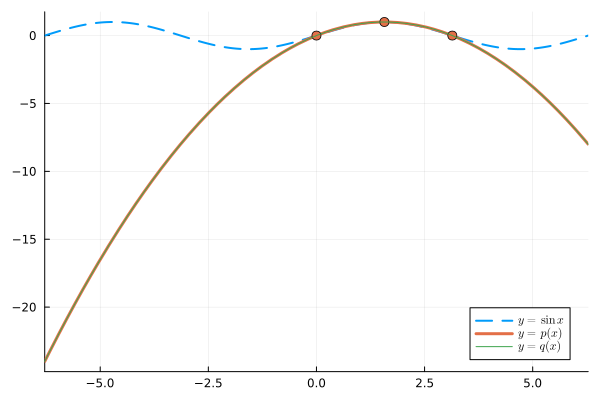

In [ ]:
q = (2/π)* Polynomial([0,1,]) - (4/pi^2) * Polynomial( [0, -pi/2, 1] )
plot!(q, xlims=(-2pi,2pi), label=L"y=q(x)")

:::

:::

Notice that if $p$ interpolates $f$ at $X = \{x_0,\dots,x_n\}$ and the $x_j$ are distinct, then

$$
\begin{align}
    p(x) &= a_0 + a_1 (x - x_0) + a_2 (x-x_0)(x-x_1) + \cdots + a_n (x-x_0)(x-x_1) \cdots (x - x_{n-1})\nonumber\\
    %
    &= f(x_0) + \frac{f(x_1) - f(x_0)}{x_1 - x_0} (x-x_0) + a_2 \pi_2(x) + \cdots + a_n \pi_n(x)
\end{align}
$$

::: {#def-divided-diff}

We define the *divided difference* $f[x_{0}, \dots, x_n]$ to be the leading coefficient in the polynomial interpolation $p\in \mathcal P_n$ of $f$ on the set of distinct nodes $X = \{x_0,x_1,\dots, x_n\}$: that is, 

$$
\begin{align}
    p(x) = f[x_0,\dots,x_n] x^n + q(x)
\end{align}
$$

where $q \in \mathcal P_{n-1}$.

:::


We have seen that $f[x_0] = f(x_0)$ and $f[x_0,x_1] = \frac{f(x_1) - f(x_0)}{x_1 - x_0}$. (Here, we just solved $p(x_0) = f(x_0)$ and $p(x_1) = f(x_1)$). 


::: {#thm-divided-diffs-1}

The divided difference $f[x_{0}, \dots, x_n]$ doesn't depend on the ordering of the interpolation nodes. Moreover, we have *linearity*: $(f + c g)[x_0,...,x_n] = f[x_0,...,x_n] + c g[x_0,...,x_n]$.

:::

**Proof.** The polynomial interpolant $p\in \mathcal P_n$ of $f$ on $X$ is independent of the ordering of the nodes. 

Moreover, if $p$ and $q$ are the polynomial interpolants of $f$ and $g$, respectively, then $p + c q$ is a polynomial interpolant of $f+ c g$. $\square$


::: {#thm-divided-diffs-2}

Suppose $X = \{x_0,\cdots,x_n\}$ is a set of $n+1$ distinct interpolation nodes. Then, we have the recursion

$$
\begin{align}
    f[x_0, \dots, x_n] &= \frac
        {f[x_1, \dots, x_n] - f[x_0, \dots, x_{n-1}]}
        {x_n - x_0}.
\end{align}
$$

:::

**Proof.** Let $p \in \mathcal P_{n-1}$ be the polynomial interpolation of $f$ on $\{x_0,\dots, x_{n-1}\}$ and define $g(x) := (x-x_{n})f(x)$ and $q(x) := (x - x_{n}) p(x)$. Then $q(x_j) = g(x_j)$ for $j = 0, \dots, n-1$ (because $p(x_j) = f(x_j)$) and $q(x_n) = 0 = g(x_n)$. Since $q \in \mathcal P_n$, $q$ is the polynomial interpolation of $g$ on $X$. Therefore, the leading coefficient of $q$ is both $g[x_0,\dots,x_{n}]$ (because $q$ interpolates $g$ on $X$) and $f[x_0,\dots,x_{n-1}]$ (because $q$ is $(x-x_{n})$ times $p$).

That is, we have $\big( (x - x_n) f \big) [x_0,\dots,x_n] = f[x_0,\dots,x_{n-1}]$. By relabeling the indices (which is allowed because $f[x_0,\dots,x_n]$ does not depend on the ordering of the interpolation nodes), we also have $\big( (x - x_0) f \big) [x_0,\dots,x_n] = f[x_1,\dots,x_{n}]$. Therefore, by linearity we have

$$
\begin{align}
    (x_n - x_0) f[x_0,\dots,x_n] &= \big( (x - x_0) f - (x-x_n) f \big) [x_0,\dots,x_n] \nonumber\\
    %
    &= \big( (x - x_0) f \big) [x_0,\dots,x_n] - \big( (x-x_n) f \big) [x_0,\dots,x_n] \nonumber\\
    %
    &= f [x_1,\dots,x_n] - f [x_0,\dots,x_{n-1}] \nonumber
\end{align}
$$

$\square$

### Divided difference table

Using @thm-divided-diffs-2, we can compute all of the divided differences of $f$ on $X = \{x_0, \dots, x_n\}$ column by column in a *divided difference table*. For example, when $n = 3$:

$$
\begin{array}{c|cccc}
    x_j & f(x_j) & \text{1st} & \text{2nd} & \text{3rd} \\ \hline
    x_0 & f[x_0] & & & \\
        & & f[x_0,x_1] & & \\
    x_1 & f[x_1] & & f[x_0,x_1,x_2] & \\
        & & f[x_1,x_2] & & f[x_0,x_1,x_2,x_3] \\
    x_2 & f[x_2] & & f[x_1,x_2,x_3] & \\
        & & f[x_2,x_3] & & \\
    x_3 & f[x_3] & & &
\end{array}
$$

Starting from the values $f[x_j] = f(x_j)$, each new entry is the difference of its two neighbours in the previous column divided by the difference of the first and last nodes involved:

$$
    f[x_j, \dots, x_{j+k}] = \frac{f[x_{j+1}, \dots, x_{j+k}] - f[x_j, \dots, x_{j+k-1}]}{x_{j+k} - x_j}.
$$

Computing the whole table requires $O(n^2)$ operations. Adding a new node $x_{n+1}$ only adds a new row at the bottom of the table (one new entry in each column), which costs $O(n)$ operations.

The entries along the top diagonal of the table are exactly the coefficients of the Newton form of the polynomial interpolation:

::: {#thm-Newton-form}

Suppose $X = \{x_0, \dots, x_n\}$ is a set of $n+1$ distinct interpolation nodes. Then,

$$
    I_X f(x) = \sum_{k=0}^n f[x_0, \dots, x_k] \, \pi_k(x).
$$

:::

**Proof.** Let $p_k \in \mathcal P_k$ be the polynomial interpolation of $f$ on $\{x_0, \dots, x_k\}$. For $k \geq 1$, $p_k - p_{k-1} \in \mathcal P_k$ vanishes at $x_0, \dots, x_{k-1}$, and so $p_k - p_{k-1} = c_k \pi_k$ for some constant $c_k$. Since $p_{k-1} \in \mathcal P_{k-1}$, comparing the coefficients of $x^k$ gives $c_k = f[x_0, \dots, x_k]$. Moreover, $p_0 = f(x_0) = f[x_0] \pi_0$. Therefore, $I_X f = p_n = p_0 + \sum_{k=1}^n (p_k - p_{k-1}) = \sum_{k=0}^n f[x_0,\dots,x_k] \pi_k$. $\square$

::: {#exm-sin-Newton-table}

Let's go back to interpolating $f(x) =\sin x$ on $\{0, \frac\pi2, \pi\}$. Now add $-2\pi$ as an interpolation node and compute the new polynomial interpolant. 

We compute the divided difference table with $x_0 = 0$, $x_1 = \frac\pi2$, $x_2 = \pi$, and $x_3 = -2\pi$:

$$
\begin{array}{c|cccc}
    x_j & f(x_j) & \text{1st} & \text{2nd} & \text{3rd} \\ \hline
    0 & 0 & & & \\
      & & \frac{2}{\pi} & & \\
    \frac{\pi}{2} & 1 & & -\frac{4}{\pi^2} & \\
      & & -\frac{2}{\pi} & & -\frac{8}{5\pi^3} \\
    \pi & 0 & & -\frac{4}{5\pi^2} & \\
      & & 0 & & \\
    -2\pi & 0 & & &
\end{array}
$$

where the entries are computed using @thm-divided-diffs-2:

$$
\begin{align}
    f[x_0,x_1] &= \frac{1 - 0}{\frac\pi2 - 0} = \frac{2}{\pi}, \nonumber\\
    f[x_1,x_2] &= \frac{0 - 1}{\pi - \frac\pi2} = -\frac{2}{\pi}, \nonumber\\
    f[x_2,x_3] &= \frac{0 - 0}{-2\pi - \pi} = 0, \nonumber\\
    f[x_0,x_1,x_2] &= \frac{-\frac2\pi - \frac2\pi}{\pi - 0} = -\frac{4}{\pi^2}, \nonumber\\
    f[x_1,x_2,x_3] &= \frac{0 - \big(-\frac2\pi\big)}{-2\pi - \frac\pi2} = -\frac{4}{5\pi^2}, \nonumber\\
    f[x_0,x_1,x_2,x_3] &= \frac{-\frac{4}{5\pi^2} - \big(-\frac{4}{\pi^2}\big)}{-2\pi - 0} = -\frac{8}{5\pi^3}. \nonumber
\end{align}
$$

By @thm-Newton-form, the coefficients of the Newton form are the entries along the top diagonal of the table, and so

$$
\begin{align}
    p(x) &= 0 + \frac{2}{\pi} x - \frac{4}{\pi^2} x \big(x - \tfrac\pi2\big) \nonumber\\
    &\qquad - \frac{8}{5\pi^3} x\big(x - \tfrac\pi2\big)\big(x - \pi\big). \nonumber
\end{align}
$$

Notice that the first three terms are exactly the interpolant from @exm-Newton-1: adding a node only adds one new term to the Newton form.

We plot this:

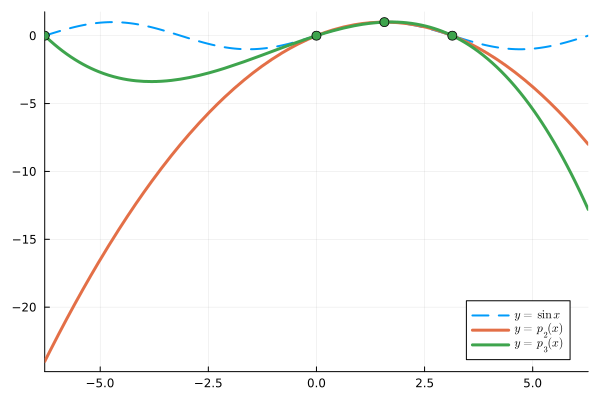

In [ ]:
r = x-> - 4*x*(x-pi)/pi^2 - 8*x*(x-pi/2)*(x-pi)/(5*pi^3)

x = [0, pi/2, pi, -2pi]
y = f.(x)

plot(f, -2pi, 2pi,  label=L"y = \sin x", lw=2, linestyle=:dash)
plot!( p, xlims=(-2pi,2pi), label=L"y= p_2(x)", lw=3)
plot!( r, xlims=(-2pi,2pi), label=L"y= p_3(x)", lw=3)
scatter!( x, y, markersize=5, primary=false)

:::

## Next time.... 

- Hermite interpolation

:::{.callout-tip}
# TO-DO

* Assignment 3 online!
* Exercises throughout the notes,
* (Sign-up to office hours if you like)

:::

## Extra exercises


::: {#exr-l08-bary-small}

Let $n = 2$ and let $X = X_{\mathrm{II}} = \big\{ \cos\frac{j\pi}{2} \big\}_{j=0}^2$ be the Chebyshev nodes of the second kind, so that $x_0 = 1$, $x_1 = 0$, and $x_2 = -1$. Compute $\lambda_0, \lambda_1, \lambda_2$ directly from the definition $\lambda_j = \big( \prod_{k\not=j} (x_j - x_k) \big)^{-1}$ and check that they agree with @eq-Barycentric-Chebyshev-II.

::: {.exercise-solution style="display: none;"}

We have
$$
\begin{align}
    \lambda_0 &= \frac{1}{(1 - 0)(1 - (-1))} = \frac12, \nonumber\\
    \lambda_1 &= \frac{1}{(0 - 1)(0 - (-1))} = -1, \nonumber\\
    \lambda_2 &= \frac{1}{(-1 - 1)(-1 - 0)} = \frac12. \nonumber
\end{align}
$$
With $n = 2$, @eq-Barycentric-Chebyshev-II gives $\lambda_0 = \frac{2^2}{8} = \frac12$, $\lambda_1 = (-1)^1 \frac{2^2}{4} = -1$, and $\lambda_2 = (-1)^2 \frac{2^2}{8} = \frac12$.

:::

:::

::: {#exr-l08-bary-weights}

In the notes, we claimed that for the Chebyshev nodes $X_{\mathrm{II}} = \big\{ x_j = \cos\frac{j\pi}{n} \big\}_{j=0}^n$ the barycentric weights $\lambda_j := \big( \prod_{k\not=j} (x_j - x_k) \big)^{-1}$ are given by

$$
    \lambda_j = \begin{cases}
        \frac{2^{n}}{4n}  & \text{if } j = 0 \\
        (-1)^j \frac{2^{n}}{2n} & \text{if } j = 1,\dots,n-1 \\
        (-1)^n \frac{2^{n}}{4n} & \text{if } j = n
    \end{cases}
$$

Prove the claim as follows:

1. Show that $\lambda_j = 1 / \ell_X'(x_j)$, where $\ell_X(x) = \prod_{k=0}^n (x - x_k)$ is the node polynomial.
2. Show that $T_n'(\cos\theta) = n \frac{\sin n\theta}{\sin\theta}$. Using @exr-l07-XII, deduce that 
$$
    \ell_X(x) = \frac{2^{1-n}}{n} (x^2 - 1) T_n'(x).
$$
3. By differentiating $T_n(\cos\theta) = \cos n\theta$ twice, show that $T_n$ satisfies the *Chebyshev differential equation* 
$$
    (1 - x^2) T_n''(x) - x T_n'(x) + n^2 T_n(x) = 0.
$$
4. Let $w(x) := (x^2-1) T_n'(x)$. Show that 
$$
    w'(x) = x T_n'(x) + n^2 T_n(x).
$$
5. Compute $w'(x_j)$ for $j = 0,\dots,n$ and conclude.
6. Explain why we may replace $\lambda_j$ by $(-1)^j$ (halved for $j = 0, n$) in the barycentric formula. Why is this a good idea when $n$ is large?

::: {.exercise-hint style="display: none;"}

For 5, treat the interior nodes and the endpoints separately: $x_1,\dots,x_{n-1}$ are the points where $T_n$ attains $\pm 1$ in $(-1,1)$. For the endpoints, evaluate the differential equation from 3 at $x = \pm 1$ to find $T_n'(\pm1)$.

:::

::: {.exercise-solution style="display: none;"}

1. Differentiating $\ell_X(x) = (x - x_j) \prod_{k\not=j} (x - x_k)$ with the product rule and setting $x = x_j$ gives $\ell_X'(x_j) = \prod_{k\not=j} (x_j - x_k) = 1/\lambda_j$.

2. Differentiating $T_n(\cos\theta) = \cos n\theta$ gives $-\sin\theta \, T_n'(\cos\theta) = -n \sin n\theta$. Therefore, with $x = \cos\theta$,
$$
    (x^2 - 1) T_n'(x) = -\sin^2\theta \cdot n \frac{\sin n\theta}{\sin \theta} = -n \sin\theta \sin n\theta = \frac{n}{2} \big( T_{n+1}(x) - T_{n-1}(x) \big)
$$
by @exr-l07-XII. Since both sides are polynomials which agree on $[-1,1]$, they are equal, and so $\ell_X(x) = 2^{-n}\big( T_{n+1}(x) - T_{n-1}(x) \big) = \frac{2^{1-n}}{n} (x^2-1) T_n'(x)$.

3. Differentiating $-\sin\theta \, T_n'(\cos\theta) = -n \sin n\theta$ again gives $\sin^2\theta \, T_n''(\cos\theta) - \cos\theta \, T_n'(\cos\theta) = -n^2 \cos n\theta = -n^2 T_n(\cos\theta)$. With $x = \cos\theta$ and $\sin^2\theta = 1 - x^2$, this is the Chebyshev differential equation on $[-1,1]$ and therefore everywhere (both sides are polynomials).

4. By the product rule, $w' = 2x T_n' + (x^2-1) T_n''$. By 3, $(x^2-1) T_n'' = n^2 T_n - x T_n'$ and so $w' = x T_n' + n^2 T_n$.

5. For $j = 1,\dots,n-1$, $T_n(x_j) = \cos j\pi = (-1)^j$ and, since $x_j$ is an interior maximum or minimum of $T_n$, $T_n'(x_j) = 0$. Therefore $w'(x_j) = n^2 (-1)^j$. 

At $x = 1$, the differential equation gives $-T_n'(1) + n^2 T_n(1) = 0$ and so $T_n'(1) = n^2$. Therefore, $w'(x_0) = w'(1) = n^2 + n^2 = 2n^2$. Similarly, at $x = -1$, we have $T_n'(-1) = -n^2 T_n(-1) = (-1)^{n+1} n^2$ and so $w'(x_n) = w'(-1) = (-1)^n n^2 + (-1)^n n^2 = 2 (-1)^n n^2$.

By 1 and 2, $\lambda_j = 1 / \ell_X'(x_j) = \frac{n 2^{n-1}}{w'(x_j)}$, which gives 
$$
\begin{align}
    \lambda_0 = \frac{n 2^{n-1}}{2n^2} = \frac{2^n}{4n}, \qquad 
    \lambda_j = \frac{n 2^{n-1}}{(-1)^j n^2} = (-1)^j \frac{2^n}{2n}, \qquad 
    \lambda_n = \frac{n 2^{n-1}}{2(-1)^n n^2} = (-1)^n \frac{2^n}{4n}. \nonumber
\end{align}
$$

6. The barycentric formula is unchanged if every $\lambda_j$ is multiplied by the same constant $c \not= 0$ (the factor $c$ cancels between the numerator and the denominator). Taking $c = \frac{2n}{2^n}$ gives the weights $(-1)^j$, halved for $j = 0, n$. For large $n$, $2^n$ overflows in floating point arithmetic (for example, `2.0^1024 == Inf`) whereas the rescaled weights are all of size $1$ or $\frac12$.

:::

:::

::: {#exr-l08-bary-equi}

Let $X = \{x_0 < \dots < x_n\}$ be the equispaced nodes on $[-1,1]$: $x_j = -1 + jh$ for $j = 0, \dots, n$, where $h = \frac2n$.

1. Show that $\prod_{k\not= j} (x_j - x_k) = (-1)^{n-j} h^n \, j!\, (n-j)!$, and deduce that the barycentric weights are
$$
    \lambda_j = \frac{(-1)^{n-j}}{h^n\, n!} \binom{n}{j}.
$$
2. Using @exr-Bary-weights, explain why we may use the weights $w_j := (-1)^j \binom{n}{j}$ in the Barycentric formula @eq-Barycentric instead. Compare the ratio $\max_j |w_j| / \min_j |w_j|$ for these weights with the same ratio for the weights $(-1)^j \tau_j$ for Chebyshev nodes ($\tau_j = \frac12$ for $j = 0,n$ and $\tau_j = 1$ otherwise) as $n \to \infty$.
3. Write a function `EquispacedInterpolant(f, n)`, analogous to `ChebyshevInterpolant` from the notes, which returns the polynomial interpolant of `f` on the equispaced nodes (using the weights $w_j$ from 2; in Julia, `binomial(n, j)` computes $\binom{n}{j}$). Compute the maximum error $\max_{t} |f(t) - I_Xf(t)|$ over the grid `range(-1, 1, length=2001)` for:
    - the Runge function $f(x) = \frac{1}{1 + 25x^2}$ with $n = 10, 20, 40$,
    - $f(x) = e^x$ with $n = 10, 20, 40, 60$.

   Compare your results with the error estimate from @thm-Lagrange-interpolation together with the bound $\| \ell_X \|_{L^\infty([-1,1])} \leq \frac{e}{2\sqrt n} \big( \frac2e \big)^n$ for equispaced nodes from Lecture 6. Comment on what you see.

::: {.exercise-hint style="display: none;"}

For 1, split the product into the terms with $k < j$ (where $x_j - x_k = (j - k)h > 0$) and the terms with $k > j$ (where $x_j - x_k = -(k - j)h < 0$). For 3, think about how errors of size $10^{-16}$ in the values $f(x_j)$ (or in the arithmetic) are amplified when the weights vary by many orders of magnitude.

:::

::: {.exercise-solution style="display: none;"}

1. For $k < j$, we have $x_j - x_k = (j-k)h$ and so $\prod_{k=0}^{j-1} (x_j - x_k) = h^j \, j!$. For $k > j$, we have $x_j - x_k = -(k-j)h$ and so $\prod_{k=j+1}^{n} (x_j - x_k) = (-1)^{n-j} h^{n-j} (n-j)!$. Multiplying gives $\prod_{k\not= j} (x_j - x_k) = (-1)^{n-j} h^n \, j! \, (n-j)!$ and therefore
$$
    \lambda_j = \frac{(-1)^{n-j}}{h^n \, j! \, (n-j)!} = \frac{(-1)^{n-j}}{h^n \, n!} \binom{n}{j}.
$$

2. We have $w_j = C \lambda_j$ with the constant $C = (-1)^n h^n n!$ (which does not depend on $j$), and so the factor $C$ cancels between the numerator and the denominator of @eq-Barycentric. The smallest weights are $|w_0| = |w_n| = 1$ and the largest is $\binom{n}{\lfloor n/2 \rfloor} \approx 2^n \sqrt{\frac{2}{\pi n}}$. Therefore, the ratio grows exponentially: it is $252$ for $n = 10$, about $1.8 \times 10^5$ for $n = 20$, and about $1.2 \times 10^{17}$ for $n = 60$. For Chebyshev nodes, the ratio is $2$ for all $n$.

3. For example:

```julia
function EquispacedInterpolant( f, n )
    x = range(-1, 1, length=n+1)
    y = f.(x)
    w = [ (-1.0)^j * binomial(n, j) for j in 0:n ]

    return function ( t )
        num = 0.0
        den = 0.0
        for j ∈ 1:(n+1)
            if t == x[j]
                return y[j]
            end
            num += w[j] * y[j] / (t - x[j])
            den += w[j] / (t - x[j])
        end
        return num / den
    end
end
```

This gives the following maximum errors:

| $n$ | Runge | $e^x$ | error bound for $e^x$ |
|---|---|---|---|
| $10$ | $1.9$ | $2.4 \times 10^{-10}$ | $1.4 \times 10^{-9}$ |
| $20$ | $6.0 \times 10^{1}$ | $1.4 \times 10^{-12}$ | $3.5 \times 10^{-23}$ |
| $40$ | $1.0 \times 10^{5}$ | $3.9 \times 10^{-7}$ | $8.2 \times 10^{-56}$ |
| $60$ | | $2.0 \times 10^{-1}$ | $9.5 \times 10^{-93}$ |

Here, the error bound is $\frac{e}{(n+1)!} \cdot \frac{e}{2\sqrt n} \big(\frac2e\big)^n$ (using $\max_{[-1,1]} |f^{(n+1)}| = e$). For the Runge function, the error grows exponentially: this is the Runge phenomenon from Lecture 6 (the derivatives of the Runge function grow too quickly for the error estimate to give convergence). For $e^x$, the exact interpolant converges extremely quickly, and the computed error decreases until $n \approx 20$. After that, the computed error *grows* even though the exact interpolant is more and more accurate. This is caused by rounding errors: perturbing the data $f(x_j)$ by $\delta_j$ changes the interpolant by $\sum_j \delta_j \ell_j(x)$, and for equispaced nodes $\max_x \sum_j |\ell_j(x)|$ grows exponentially in $n$ (like the ratio of the weights in 2). Rounding errors of size $10^{-16}$ are therefore amplified by a factor of order $2^n$. For Chebyshev nodes, this amplification factor only grows like $\log n$ (see @BerrutTrefethen2004).

:::

:::